In [1]:
import pandas as pd
import numpy as np
from ScanResult import *
from data_scan import *
from data_clean_manual import *

In [2]:
np.random.seed(42)
rows = 20

# Create sample data with 10 columns.
data = {
    "num1": np.random.randint(0, 100, size=rows),
    "num2": np.random.randn(rows) * 10,
    "cat1": np.random.choice(["apple", "banana", "cherry"], size=rows),
    "cat2": np.random.choice(["red", "green", "blue"], size=rows),
    "num3": np.random.uniform(0, 50, size=rows),
    "num4": np.random.randint(0, 200, size=rows),
    "text": [f"Sample {i}" for i in range(rows)],
    "bool": np.random.choice([True, False], size=rows),
    "num5": np.random.randn(rows) * 5,
    "cat3": np.random.choice(["X", "Y", "Z"], size=rows),
    "cat4": ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't'],
    "empty_col": [np.nan] * 20 
}
df = pd.DataFrame(data)

for col in ["num2", "num3", "text", "bool"]:
    missing_indices = np.random.choice(df.index, size=3, replace=False)
    df.loc[missing_indices, col] = np.nan

df.loc[10] = df.loc[0]
df.loc[20] = df.loc[0]

df1 = df.copy()
df2 = df.copy()
df2

,num1,num2,cat1,cat2,num3,num4,text,bool,num5,cat3,cat4,empty_col
0,51,14.623781,cherry,green,0.781820,34,Sample 0,False,-3.051610,X,a,NaN
1,92,15.387150,apple,blue,21.170074,192,Sample 1,False,-1.580829,X,b,NaN
2,14,NaN,cherry,blue,19.744076,100,Sample 2,True,-7.412121,Y,c,NaN
3,71,6.034412,cherry,green,14.674409,174,NaN,True,-1.144238,X,d,NaN
4,60,-2.510440,banana,blue,0.703991,130,NaN,True,4.813206,Y,e,NaN
5,20,-1.638671,apple,red,9.942120,0,Sample 5,True,-1.048462,Y,f,NaN
6,82,-14.763297,banana,green,35.567098,4,Sample 6,True,-3.870215,Z,g,NaN
7,86,14.869810,banana,red,NaN,141,Sample 7,NaN,-1.798891,Y,h,NaN
8,74,NaN,banana,red,30.297999,102,Sample 8,True,3.620416,Z,i,NaN
9,74,3.555513,banana,green,46.315044,26,Sample 9,False,-1.278823,X,j,NaN


In [3]:
all_null_cols = df1.columns[df1.isnull().all()]
df1.drop(columns=all_null_cols, inplace=True)
scan_results = []
scan_results.extend(scan_df_for_duplicates(df1))
scan_results.extend(scan_df_for_missing(df1))
scan_results.extend(scan_df_for_outliers(df1))
scan_results.extend(scan_df_for_categorical(df1))

scan_results.extend(scan_df_for_target(df1, target=51))

scan_results

[ScanResult(row=10, col=-1, message='Row 11 is duplicated', action_type=SRActionType.DEFAULT, actions=[ScanResultAction(title='Duplication Remover', description='Remove the duplicated rows', cleaner='clean_df_for_duplicates', cleaner_id=None, activate=True, data=None)]),
 ScanResult(row=20, col=-1, message='Row 21 is duplicated', action_type=SRActionType.DEFAULT, actions=[ScanResultAction(title='Duplication Remover', description='Remove the duplicated rows', cleaner='clean_df_for_duplicates', cleaner_id=None, activate=True, data=None)]),
 ScanResult(row=2, col=num2, message='Missing value in row 3, column 'num2'', action_type=SRActionType.DEFAULT, actions=[ScanResultAction(title='Missing Value Filler', description='Fill with mean value', cleaner='fill_with_mean', cleaner_id=None, activate=True, data=None), ScanResultAction(title='Missing Value Filler', description='Fill with median value', cleaner='fill_with_median', cleaner_id=None, activate=True, data=None), ScanResultAction(title='M

In [4]:
import random

def choose_one_action_per_scan_result(scan_results):
    for sr in scan_results:
        if sr.actions:
            chosen_action = random.choice(sr.actions)
            for action in sr.actions:
                action.activate = False
            chosen_action.activate = True
            sr.actions = [chosen_action]
    return scan_results


chosen_scan_results = choose_one_action_per_scan_result(scan_results)

chosen_scan_results


[ScanResult(row=10, col=-1, message='Row 11 is duplicated', action_type=SRActionType.DEFAULT, actions=[ScanResultAction(title='Duplication Remover', description='Remove the duplicated rows', cleaner='clean_df_for_duplicates', cleaner_id=None, activate=True, data=None)]),
 ScanResult(row=20, col=-1, message='Row 21 is duplicated', action_type=SRActionType.DEFAULT, actions=[ScanResultAction(title='Duplication Remover', description='Remove the duplicated rows', cleaner='clean_df_for_duplicates', cleaner_id=None, activate=True, data=None)]),
 ScanResult(row=2, col=num2, message='Missing value in row 3, column 'num2'', action_type=SRActionType.DEFAULT, actions=[ScanResultAction(title='Missing Value Filler', description='Fill with previous value', cleaner='fill_with_ffill', cleaner_id=None, activate=True, data=None)]),
 ScanResult(row=3, col=text, message='Missing value in row 4, column 'text'', action_type=SRActionType.DEFAULT, actions=[ScanResultAction(title='Missing Value Filler', descrip

In [ ]:
for scan_result in scan_results:
    if scan_result.action_type == SRActionType.DEFAULT:
        if "duplicated" in scan_result.message:
            df1 = clean_df_for_duplicates(scan_result, df1)
        elif "Missing value" in scan_result.message:
            df1 = clean_df_for_missing(scan_result, df1)
        elif "Outlier detected" in scan_result.message:
            df1 = clean_df_for_outlier(scan_result, df1)
        elif "Categorical feature" in scan_result.message:
            df1 = clean_df_for_categorical(scan_result, df1)

df1


,num1,num2,cat1,cat2,num3,num4,text,bool,num5,cat3,cat4
0,51,14.623781,cherry,green,0.781820,34,Sample 0,0,-3.051610,X,a
1,92,15.387150,apple,blue,21.170074,192,Sample 1,0,-1.580829,X,b
2,14,15.387150,cherry,blue,19.744076,100,Sample 2,1,-7.412121,Y,c
3,71,6.034412,cherry,green,14.674409,174,Sample 2,1,-1.144238,X,d
5,20,-1.638671,apple,red,9.942120,0,Sample 5,1,-1.048462,Y,f
6,82,-14.763297,banana,green,35.567098,4,Sample 6,1,-3.870215,Z,g
7,86,14.869810,banana,red,30.297999,141,Sample 7,1,-1.798891,Y,h
9,74,3.555513,banana,green,46.315044,26,Sample 9,0,-1.278823,X,j
11,99,8.324619,banana,red,45.747984,14,Sample 11,0,-6.556621,X,l
12,23,-2.933991,banana,green,22.472534,89,Sample 12,1,-4.351525,X,m


In [6]:
from data_clean_auto import *
df2

,num1,num2,cat1,cat2,num3,num4,text,bool,num5,cat3,cat4,empty_col
0,51,14.623781,cherry,green,0.781820,34,Sample 0,False,-3.051610,X,a,NaN
1,92,15.387150,apple,blue,21.170074,192,Sample 1,False,-1.580829,X,b,NaN
2,14,NaN,cherry,blue,19.744076,100,Sample 2,True,-7.412121,Y,c,NaN
3,71,6.034412,cherry,green,14.674409,174,NaN,True,-1.144238,X,d,NaN
4,60,-2.510440,banana,blue,0.703991,130,NaN,True,4.813206,Y,e,NaN
5,20,-1.638671,apple,red,9.942120,0,Sample 5,True,-1.048462,Y,f,NaN
6,82,-14.763297,banana,green,35.567098,4,Sample 6,True,-3.870215,Z,g,NaN
7,86,14.869810,banana,red,NaN,141,Sample 7,NaN,-1.798891,Y,h,NaN
8,74,NaN,banana,red,30.297999,102,Sample 8,True,3.620416,Z,i,NaN
9,74,3.555513,banana,green,46.315044,26,Sample 9,False,-1.278823,X,j,NaN


,num1,num2,cat1,cat2,num3,num4,text,bool,num5,cat3,cat4
0,51.0,14.623781,cherry,green,0.781820,34.0,Sample 0,False,-3.051610,X,a
1,92.0,15.387150,apple,blue,21.170074,192.0,Sample 1,False,-1.580829,X,b
2,14.0,1.010799,cherry,blue,19.744076,100.0,Sample 2,True,-7.412121,Y,c
3,71.0,6.034412,cherry,green,14.674409,174.0,Sample 0,True,-1.144238,X,d
4,60.0,-2.510440,banana,blue,0.703991,130.0,Sample 0,True,4.813206,Y,e
5,20.0,-1.638671,apple,red,9.942120,0.0,Sample 5,True,-1.048462,Y,f
6,82.0,-14.763297,banana,green,35.567098,4.0,Sample 6,True,-3.870215,Z,g
7,86.0,14.869810,banana,red,22.523564,141.0,Sample 7,True,-1.798891,Y,h
8,74.0,2.974192,banana,red,30.297999,102.0,Sample 8,True,3.620416,Z,i
9,74.0,3.555513,banana,green,46.315044,26.0,Sample 9,False,-1.278823,X,j


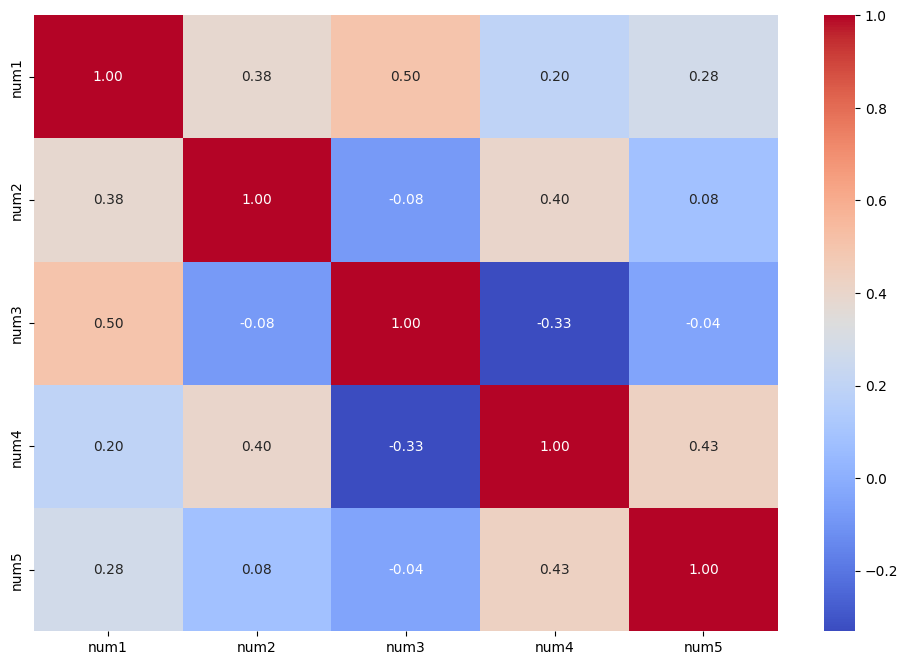

In [7]:
df2 = clean_data(df2, handle_dates=True, generate_report=True)
df2